# MNA, one stamp at a time

This is the first Chapter 2 session. We will assemble and solve one small circuit by hand, then compare it with the project code.

**Prerequisites:** node voltage, KCL, Ohm's law, and basic Python/NumPy.

**Objectives:** choose MNA unknowns, translate each element into a stamp, read the final equations, solve them, and check the residual.

```text
       R1 = 1 kOhm       R2 = 2 kOhm
  1 o------/\/\------o 2------/\/\------o ground
    |                                  |
   +| V1 = 5 V                    I1 = 1 mA
    |                              arrow: 2 -> ground
  ground
```

Each element adds a local rule to the global system $A x = b$. Nothing is solved until all stamps are present.

## 1. Choose the unknowns

Ground is node 0, so $V_0=0$ is known and needs no unknown. The non-ground node voltages are $V_1$ and $V_2$.

An ideal voltage source needs one extra unknown current because Ohm's law does not determine its current. We call it $I_{V1}$.

Our unknown vector is:

$$x = [V_1, V_2, I_{V1}]^T$$

So $x$ has shape $(3,)$, $A$ has shape $(3,3)$, and $b$ has shape $(3,)$.

The ordering is not cosmetic: it tells us which row and column each stamp must modify.

In [ ]:
import numpy as np

unknowns = ['V(1)', 'V(2)', 'I(V1)']
node_indices = {1: 0, 2: 1}
branch_indices = {'V1': 2}

print('unknowns:', unknowns)
print('node indices:', node_indices)
print('branch indices:', branch_indices)

unknowns: ['V(1)', 'V(2)', 'I(V1)']
node indices: {1: 0, 2: 1}
branch indices: {'V1': 2}


## 2. From equations to an algorithm

MNA is a repeatable bookkeeping algorithm:

1. List non-ground nodes and assign matrix indices.
2. Add one unknown and one row/column for each ideal voltage source.
3. Start $A$ and $b$ at zero.
4. Stamp each element into its indexed entries.
5. Solve $A x=b$ and calculate the residual $r=b-Ax$.

The first two rows are KCL equations. The final row is the voltage-source constraint $V_1-V_0=5$. The matching final column lets the unknown source current participate in node 1's KCL equation.

This is the central translation for the session: **physical law -> local stamp -> global linear system**.

In [ ]:
size = len(unknowns)
A = np.zeros((size, size), dtype=float)
b = np.zeros(size, dtype=float)

def show_state(label):
    print(f'\n{label}')
    print('A =')
    print(A)
    print('b =', b)

show_state('Initial empty system')


Initial empty system
A =
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
b = [0. 0. 0.]


## 3. Stamp the 1 kOhm resistor

For a resistor, $G=1/R$. A resistor between nodes $p$ and $n$ contributes this local rule:

$$
\begin{bmatrix}
+G & -G \\
-G & +G
\end{bmatrix}
$$

The four entries go into the rows and columns for $p$ and $n$. Here $G_1=1/1000=0.001$ S. The units matter: conductance times voltage gives current.

In [ ]:
R1 = 1000.0
G1 = 1 / R1
p, n = node_indices[1], node_indices[2]
A[p, p] += G1
A[n, n] += G1
A[p, n] -= G1
A[n, p] -= G1
show_state('After stamping R1 between nodes 1 and 2')


After stamping R1 between nodes 1 and 2
A =
[[ 0.001 -0.001  0.   ]
 [-0.001  0.001  0.   ]
 [ 0.     0.     0.   ]]
b = [0. 0. 0.]


## 4. Stamp the 2 kOhm resistor to ground

R2 connects node 2 to ground. Ground has no row or column, so only the node-2 diagonal receives $G_2 = 1/2000 = 0.0005$ siemens. This is why the production code checks for `None` when a terminal is ground.

In [ ]:
R2 = 2000.0
G2 = 1 / R2
node_2 = node_indices[2]
A[node_2, node_2] += G2
show_state('After stamping R2 between node 2 and ground')


After stamping R2 between node 2 and ground
A =
[[ 0.001  -0.001   0.    ]
 [-0.001   0.0015  0.    ]
 [ 0.      0.      0.    ]]
b = [0. 0. 0.]


## 5. Stamp the 1 mA current source

The source arrow is from node 2 to ground: current leaves node 2. In the sign convention used by this project, that means subtract $1$ mA from the node-2 entry of $b$. It changes the right-hand side, not the matrix.

This is worth noticing: resistors describe how voltages create currents, while independent current sources directly inject or remove current in KCL.

In [ ]:
I1 = 0.001
b[node_2] -= I1
show_state('After stamping I1 from node 2 to ground')


After stamping I1 from node 2 to ground
A =
[[ 0.001  -0.001   0.    ]
 [-0.001   0.0015  0.    ]
 [ 0.      0.      0.    ]]
b = [ 0.    -0.001  0.   ]


## 6. Stamp the voltage source

For `V1`, add a new row and column for $I_{V1}$. The `+1` and `-1` entries connect that current to the node KCL equations. The new row encodes the voltage constraint $V_1 - V_0 = 5$.

Because the negative terminal is ground, only node 1 gets a coupling entry.

In [ ]:
branch = branch_indices['V1']
positive = node_indices[1]
A[positive, branch] += 1.0
A[branch, positive] += 1.0
b[branch] += 5.0
show_state('Final assembled MNA system')


Final assembled MNA system
A =
[[ 0.001  -0.001   1.    ]
 [-0.001   0.0015  0.    ]
 [ 1.      0.      0.    ]]
b = [ 0.e+00 -1.e-03  5.e+00]


## 7. Read the equations hidden inside `A @ x = b`

The final numbers are easier to understand in equations. With conductances in siemens:

$$0.001V_1 - 0.001V_2 + I_{V1} = 0$$
$$-0.001V_1 + 0.0015V_2 = -0.001$$
$$V_1 = 5$$

The first two equations are KCL. The third is the voltage-source constraint.

In [ ]:
x = np.linalg.solve(A, b)
print('solution [V(1), V(2), I(V1)] =', x)
print(f'V1 = {x[0]:.3f} V')
print(f'V2 = {x[1]:.3f} V')
print(f'I(V1) = {x[2] * 1000:.3f} mA')
print('residual A @ x - b =', A @ x - b)

solution [V(1), V(2), I(V1)] = [ 5.00000000e+00  2.66666667e+00 -2.33333333e-03]
V1 = 5.000 V
V2 = 2.667 V
I(V1) = -2.333 mA
residual A @ x - b = [0. 0. 0.]


## 8. Check against the project implementation

The teaching code above is intentionally explicit. The package version compresses the same rules into reusable stamping helpers. This final check makes the connection concrete: both paths should produce the same matrix and RHS.

In [ ]:
from circuit_sim.mna import assemble_mna

circuit = [
    {'name': 'V1', 'type': 'V', 'positive_node': 1, 'negative_node': 0, 'voltage': 5.0},
    {'name': 'R1', 'type': 'R', 'positive_node': 1, 'negative_node': 2, 'resistance': 1000.0},
    {'name': 'R2', 'type': 'R', 'positive_node': 2, 'negative_node': 0, 'resistance': 2000.0},
    {'name': 'I1', 'type': 'I', 'positive_node': 2, 'negative_node': 0, 'current': 0.001},
]
production_system = assemble_mna(circuit)
print('Matrices match:', np.allclose(A, production_system['matrix']))
print('RHS vectors match:', np.allclose(b, production_system['rhs']))
print('Production matrix:')
print(production_system['matrix'])
print('Production RHS:', production_system['rhs'])

Matrices match: True
RHS vectors match: True
Production matrix:
[[ 0.001  -0.001   1.    ]
 [-0.001   0.0015  0.    ]
 [ 1.      0.      0.    ]]
Production RHS: [ 0.e+00 -1.e-03  5.e+00]


## Completion checkpoint

You have completed this session when you can answer these without looking back:

1. Why does ground have no row or column?
2. Why does an ideal voltage source add both an unknown current and an equation?
3. Which entry changes when a current source points from node 2 to ground?
4. Why is $r=b-Ax$ close to zero after solving?

**Expected results:** $V_1=5$ V, $V_2\approx2.667$ V, $I_{V1}\approx-2.333$ mA, and a zero residual to numerical precision.

Stop here and answer the questions before moving to a second voltage source or a source between two non-ground nodes.

## 8. Verify the public circuit-simulation pipeline

The hand assembly above explains the equations. Now use the package boundary that a user or the viewer uses: parse a netlist, assemble MNA, solve it with the educational LU implementation, and inspect the residual. The same circuit is intentionally used so the two paths can be compared.

unknowns: ['V(1)', 'V(2)', 'I(V1)']
linear solution: [ 5.00000000e+00  2.66666667e+00 -2.33333333e-03]
linear residual norm: 0.0
DC residual norm: 2.168404344971009e-19


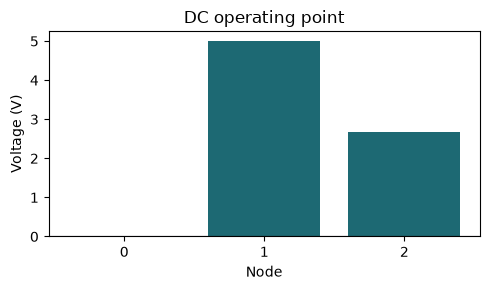

In [ ]:
import sys

import matplotlib.pyplot as plt

sys.path.insert(0, "src")

from circuit_sim.dc import solve_dc
from circuit_sim.mna import assemble_mna
from circuit_sim.parser import parse_netlist
from circuit_sim.solver import solve_linear_system
from circuit_sim.viewer import draw_solution_plot

netlist = """V1 1 0 5
R1 1 2 1000
R2 2 0 2000
I1 2 0 0.001"""
circuit = parse_netlist(netlist)
system = assemble_mna(circuit)
linear_result = solve_linear_system(system["matrix"], system["rhs"])
dc_result = solve_dc(circuit)

print("unknowns:", system["unknowns"])
print("linear solution:", linear_result["solution"])
print("linear residual norm:", linear_result["residual_norm"])
print("DC residual norm:", dc_result["residual_norm"])

figure = plt.figure(figsize=(5, 3))
draw_solution_plot(figure, dc_result)
plt.show()